In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler

from utilities.preprocess import preprocess_data, fillna, one_hot_encode, add_new_features

In [2]:
dataset = pd.read_excel('data/Training.xlsx')
dataset = preprocess_data(dataset)
dataset = add_new_features(dataset)
dataset = fillna({'train': dataset})['train']
dataset = one_hot_encode(dataset)

In [3]:
features = dataset.drop(columns=['target'])
target = dataset['target']

Абярэм найбольш карысныя прыкметы па каэфіцыенту ўзаемнай інфармацыі з метавай пераменнай.

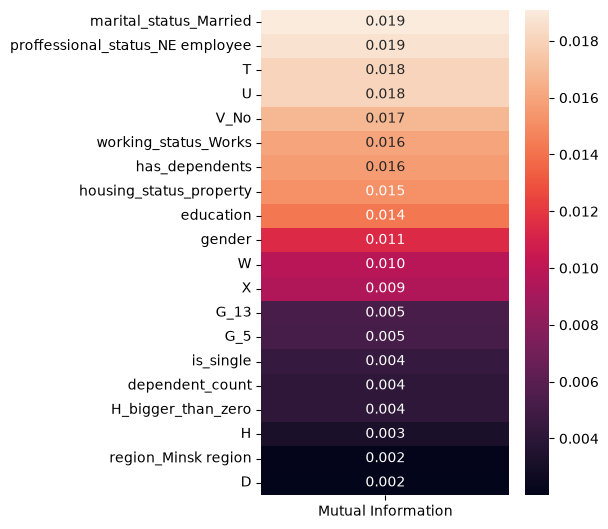

In [4]:
mi = mutual_info_classif(features, target, random_state=42)

mi_df = pd.DataFrame({
    'Mutual Information': mi
}, index=features.columns)

mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

plt.figure(figsize=(4, len(mi_df) * 0.1 + 1))
sns.heatmap(
    mi_df.head(20),
    annot=True,
    fmt='.3f',
)
plt.show()

In [5]:
informative_features = mi_df[mi_df['Mutual Information'] >= 1e-3].index.tolist()
informative_features

['marital_status_Married',
 'proffessional_status_NE employee',
 'T',
 'U',
 'V_No',
 'working_status_Works',
 'has_dependents',
 'housing_status_property',
 'education',
 'gender',
 'W',
 'X',
 'G_13',
 'G_5',
 'is_single',
 'dependent_count',
 'H_bigger_than_zero',
 'H',
 'region_Minsk region',
 'D',
 'G_3',
 'R',
 'F',
 'region_Minsk',
 'C',
 'marital_status_Single/unmarried',
 'G_10',
 'marital_status_Divorced/widow',
 'working_status_Unemployed',
 'E']

Таксама зробім адбор прыкмет праз навучанне рэгрэсіі з L1 рэгулярызацыяй.

In [6]:
scaler = StandardScaler()

scaled_dataset = scaler.fit_transform(dataset.drop(columns=['target']))

logistic_regression = LogisticRegressionCV(
    l1_ratios=(1,),
    solver="saga",
    cv=5,
    scoring="average_precision",
    class_weight="balanced",
    Cs=8,
    max_iter=5000,
    random_state=42,
    n_jobs=-1,
    tol=1e-3
)

logistic_regression.fit(scaled_dataset, dataset['target'])

d:\work_search_tests\default_detection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",8
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.","(1,)"
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy <accuracy_score>` is used... versionchanged:: 1.11 The default will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11.",'average_precision'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) chosen and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... versionadded:: 0.17 

In [9]:
coef = logistic_regression.coef_.flatten()

importance = pd.DataFrame({
    "Feature": dataset.drop(columns=['target']).columns,
    "coefficient": np.abs(coef)
})

selected_features = importance[importance["coefficient"] != 0].sort_values("coefficient", ascending=False)
regression_selected_features = selected_features["Feature"].tolist()
regression_selected_features

['G_13',
 'L',
 'education',
 'D',
 'R',
 'G_5',
 'W',
 'H',
 'X',
 'working_status_Pensioner',
 'is_single',
 'marital_status_Married',
 'gender',
 'F',
 'proffessional_status_Head/Deputy head (organiz.)',
 'B',
 'age',
 'U',
 'has_dependents',
 'G_6',
 'region_Grodno region',
 'G_4',
 'G_10',
 'marital_status_Divorced/widow',
 'proffessional_status_NE employee',
 'Y',
 'G_24',
 'region_Mogilev region',
 'housing_status_rent/hire',
 'region_Minsk',
 'region_Vitebsk region',
 'housing_status_property',
 'region_Gomel region',
 'G_9',
 'A']

Сфармуем выніковы спіс праз аб'яднанне мностваў атрыманых пра каэфіцыент узаемнай інфармацыі і праз зануленне каэфіцыентаў у рэгрэсіі

In [10]:
final_features = list(set(informative_features) | set(regression_selected_features))
final_features

['region_Gomel region',
 'V_No',
 'housing_status_property',
 'marital_status_Single/unmarried',
 'region_Vitebsk region',
 'G_5',
 'W',
 'region_Minsk region',
 'T',
 'A',
 'G_4',
 'G_6',
 'gender',
 'H_bigger_than_zero',
 'G_13',
 'region_Grodno region',
 'U',
 'B',
 'X',
 'proffessional_status_NE employee',
 'proffessional_status_Head/Deputy head (organiz.)',
 'F',
 'has_dependents',
 'working_status_Pensioner',
 'G_24',
 'G_9',
 'marital_status_Married',
 'C',
 'L',
 'marital_status_Divorced/widow',
 'region_Minsk',
 'R',
 'E',
 'D',
 'H',
 'education',
 'working_status_Unemployed',
 'G_10',
 'housing_status_rent/hire',
 'working_status_Works',
 'age',
 'is_single',
 'G_3',
 'dependent_count',
 'region_Mogilev region',
 'Y']